In [1]:
%load_ext autoreload
%autoreload 2 

In [2]:
import wandb
import torch.nn as nn
import torch
import numpy as np
import hydra
import einops
import os
import sys
from pathlib import Path
from dynamics_modeling.eval import batch_eval_loop
from torch.utils.data import DataLoader


os.environ["WANDB_DIR"] = '/pscratch/sd/g/gzhao27/INR/coral/wandb'
os.environ["RESULTS_DIR"] = ''

# sys.path.append(str(Path(__file__).parents[1]))
sys.path.append('/pscratch/sd/g/gzhao27/INR/coral')
sys.path.append('/pscratch/sd/g/gzhao27/INR/SOMA')
from coral.utils.plot import show
from coral.metalearning import graph_outer_step as outer_step
from coral.utils.models.scheduling import ode_scheduling
from coral.utils.models.load_inr import create_inr_instance, load_inr_model
from coral.utils.models.get_inr_reconstructions import get_reconstructions
from coralsoma.load_modulations import load_graph_modulations, graph_ode_inr_predict
from coral.utils.data.load_data import get_dynamics_data, set_seed
from coral.utils.data.dynamics_dataset import (KEY_TO_INDEX, TemporalDatasetWithCode)
from coral.mlp import Derivative
from torchdiffeq import odeint
from omegaconf import DictConfig, OmegaConf
from utils.data.unstructure_dataset import GraphNavierStokes, collate_graph_inr, GraphSomaDataset, GraphBurgers

# with hydra.initialize(config_path="../config/"):
#     # Compose the configuration (equivalent to loading ode.yaml)
#     cfg = hydra.compose(config_name="ode.yaml")'


device = torch.device("cpu")

2024-12-30 18:46:55.580124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-30 18:46:55.743826: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-30 18:46:55.809468: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-30 18:46:56.196367: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-30 18:46:58.853813: W tensorflow/compiler/tf2

### Test SOMA INR

In [3]:

input_dim = 3
output_dim = 1

# ode_save_name = "NS_test_ode"
# inr_save_path = '/pscratch/sd/g/gzhao27/INR/SOMA/2024-11-29SOMA-inr_w010_ld256.pt'
inr_save_path = '/pscratch/sd/g/gzhao27/INR/SOMA/2024-12-25SOMA-inr_w09_lr2.790331349348974e-05_depth6_hdim94.pt'
inr_results = torch.load(inr_save_path)

cfg = inr_results['cfg']
alpha = inr_results['alpha']
print('epoch number:')
inr_results['epoch']

/tmp/ipykernel_1398350/3324024149.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  inr_results = torch.load(inr_save_path)


RuntimeError: CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [4]:
torch.set_default_dtype(torch.float32)
# submitit.JobEnvironment()
# data
saved_checkpoint = cfg.wandb.saved_checkpoint
if saved_checkpoint:
    entity = cfg.wandb.entity
    project = cfg.wandb.project
    run_id = cfg.wandb.id
    run_name = cfg.wandb.name
    checkpoint = torch.load(cfg.wandb.checkpoint_path)
    cfg = checkpoint['cfg']
elif saved_checkpoint == False:
    #wandb
    entity = cfg.wandb.entity
    project = cfg.wandb.project
    run_id = cfg.wandb.id
    run_name = cfg.wandb.name

#data
data_dir = cfg.data.dir
dataset_name = cfg.data.dataset_name
ntrain = cfg.data.ntrain
ntest = cfg.data.ntest
data_to_encode = cfg.data.data_to_encode
# sub_from = cfg.data.sub_from
space_factor = cfg.data.space_factor
time_factor = cfg.data.time_factor
seed = cfg.data.seed
same_grid = cfg.data.same_grid
seq_inter_len = cfg.data.seq_inter_len
seq_extra_len = cfg.data.seq_extra_len
missing_rate = cfg.data.missing_rate

# optim
batch_size = cfg.optim.batch_size
batch_size_val = (
    batch_size if cfg.optim.batch_size_val == None else cfg.optim.batch_size_val
)
lr_inr = cfg.optim.lr_inr
gamma_step = cfg.optim.gamma_step
lr_code = cfg.optim.lr_code
meta_lr_code = cfg.optim.meta_lr_code
weight_decay_code = cfg.optim.weight_decay_code
inner_steps = cfg.optim.inner_steps
test_inner_steps = cfg.optim.test_inner_steps
epochs = cfg.optim.epochs

# inr
model_type = cfg.inr.model_type
latent_dim = cfg.inr.latent_dim


In [5]:
mmap_dir = '/pscratch/sd/g/gzhao27/INR/SOMA/results/soma_mmap_save'
testset = GraphSomaDataset(
            data_path='/global/cfs/cdirs/m4259/ecucuzzella/soma_ppe_data/ml_converted/month_1/thedataset-impliciBottomDrag.hdf5',
            data_num=80, 
            feature_set=[10],
            space_factor=4,
            time_factor=2, 
            latent_dim=latent_dim,
            split='test',
            mmap_dir=mmap_dir,
        )

/pscratch/sd/g/gzhao27/INR/SOMA/utils/data/unstructure_dataset.py:385: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  return torch.from_numpy(self.mmap_data[rawidx])
/pscratch/sd/g/gzhao27/conda/coral/lib/python3.9/site-packages/torch/functional.py:513: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3609.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [53]:
feat_transform = inr_results['feat_transform']
feat_inv_transform = inr_results['feat_inv_transform']
testset.update_feat_transform(feat_transform)

In [6]:
# dataloader
test_loader = DataLoader(dataset=testset, batch_size=80, shuffle=True, collate_fn=collate_graph_inr)
inr = create_inr_instance(
    cfg, input_dim=input_dim, output_dim=output_dim, device=device
)
for substep, graph in enumerate(test_loader):
    pass

In [22]:
sub_array_num = 5
graph_T = graph.time[-1]+1 
base_size = graph_T//sub_array_num
extra = graph_T % sub_array_num

indexes = []
start = 0
for i in range(sub_array_num):
    end = start + base_size + (1 if i<extra else 0)
    indexes.append(list(range(start, end)))
    start = end
    
# sub_array_T = [base_size + 1 if i < extra else base_size for i in range(sub_array_num)]

# graph.time == 0

In [35]:
graph

DataBatch(time=[8065200], cor=[8065200, 3], feat=[8065200, 1], T=[80], latent_vector=[1200, 180], pde_parameter=[80], space_emb=[8065200, 3])

In [33]:
graph.feat[torch.isin(graph.time, torch.tensor(indexes[0]))].shape

torch.Size([1613040, 1])

In [34]:
1613040*5

8065200

In [21]:
sub_array_T

[tensor(240, dtype=torch.int32),
 tensor(240, dtype=torch.int32),
 tensor(240, dtype=torch.int32),
 tensor(240, dtype=torch.int32),
 tensor(240, dtype=torch.int32)]

In [20]:
graph.feat.shape

torch.Size([8065200, 1])

In [19]:
graph.feat[graph.time == 0].shape

torch.Size([6721, 1])

In [14]:
sub_array_T

[tensor(240, dtype=torch.int32),
 tensor(240, dtype=torch.int32),
 tensor(240, dtype=torch.int32),
 tensor(240, dtype=torch.int32),
 tensor(240, dtype=torch.int32)]

In [7]:
# load inr
model_state_dict = inr_results['inr']
# model = Derivative(output_dim, latent_dim, hidden, depth).cuda()
inr.load_state_dict(model_state_dict)

<All keys matched successfully>

In [8]:
# predict reconstruction
inr.eval()
n_samples = len(graph)
batch_idx = 0

graph.images = graph.feat
graph.pos = graph.space_emb
graph.batch = graph.time
graph.modulations = torch.zeros(graph.T.sum(), latent_dim) #torch.zeros_like(graph.latent_vector)
# graph.modulations = torch.zeros_like(graph.latent_vector)
inr.to(device)
graph.to(device)
alpha = alpha.to(device)
outputs = outer_step(
    inr,
    graph,
    inner_steps,
    alpha,
    is_train=False,
    return_reconstructions=False,
    gradient_checkpointing=False,
    use_rel_loss=False,
    loss_type="mse",
)
predict_modulation = outputs['modulations']

graphbatch= graph[batch_idx].time
pos = graph[batch_idx].space_emb
features_recon = inr.modulated_forward(pos, predict_modulation[graphbatch])
graph0 = graph[batch_idx]


In [14]:
feat_inv_transform = inr_results['feat_inv_transform']

In [15]:
features_recon = feat_inv_transform(features_recon)

In [10]:
features = graph0.feat
features_recon = feat_inv_transform(features_recon)
features = feat_inv_transform(features)

NameError: name 'feat_inv_transform' is not defined

In [16]:
((features_recon - features) ** 2).mean()

tensor(109.3651)

In [25]:
graph.images.std()

tensor(1.2413)

In [21]:
features_recon

tensor([[0.0226],
        [0.0225],
        [0.0116],
        ...,
        [0.0042],
        [0.0072],
        [0.0069]])

In [20]:
outputs['loss']

tensor(2.0530)

In [11]:
# image generate function
Z, X, Y= graph[0].cor.max(dim=0).values+1

def graph2image(graph, image_pred):
    
    T = graph.T.item()
    
    video_gt = np.empty((T, Z, X, Y))
    
    video_pred = np.empty((T, Z, X, Y))
    video_gt[:]=np.nan
    video_pred[:] = np.nan
    
    
    for t in range(T):
        tidx = (graph.time%T ==t)
        coordinates = graph.cor[tidx]
        values_gt = graph.feat[tidx]
        if image_pred is not None:
            values_pred = image_pred[tidx]
        # zidx = coordinates[:, 0] == Z
        # coordinates = coordinates[zidx]
        # values_gt = values_gt[zidx]
        # values_pred = values_pred[zidx]
        
        coordinates_np = coordinates.numpy()
        values_gt = values_gt.numpy().reshape(-1)
        if image_pred is not None:
            values_pred = values_pred.numpy().reshape(-1)
        
        for i, (z, x, y) in enumerate(coordinates_np):
            video_gt[t, z, x, y,] = values_gt[i]
            video_pred[t, z, x, y,] = values_pred[i] if image_pred is not None else 0.
    
    return video_gt, video_pred

In [17]:

features_recon = features_recon.detach()
video_gt, video_inr = graph2image(graph0, features_recon)

In [119]:
graph0 = graph[0]
features_recon = graph0.feat
video_gt, video_inr = graph2image(graph0, features_recon)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML

# Assuming your tensor is a 3D numpy array of shape (50, 64, 64)
tensor1 = np.transpose(video_gt, (1, 0, 2, 3)).reshape(-1, X, Y)[:120]  # Replace this with your actual tensor
tensor2 = np.transpose(video_inr, (1, 0, 2, 3)).reshape(-1, X, Y)[:120]
# tensor3 = video_pred

# Create a figure and axis to display the images
fig, (ax1, ax2) = plt.subplots(1, 2)

# Display the first frame
im1 = ax1.imshow(tensor1[0])
im2 = ax2.imshow(tensor2[0])
# im3 = ax3.imshow(tensor3[0], vmax = 1.5, vmin = -1.5)

# Add colorbars
cbar1 = fig.colorbar(im1, ax=ax1)
cbar1.set_label('Ground Truth Intensity')

cbar2 = fig.colorbar(im2, ax=ax2)
cbar2.set_label('Normalized Intensity')


ax1.set_title('Ground Truth')
ax2.set_title('normalized')


# Update function for animation
def update(frame):
    im1.set_array(tensor1[frame])
    im2.set_array(tensor2[frame])
    # im3.set_array(tensor2[frame])
    # return [im1, im2, im3]
    return [im1, im2]


# Create an animation
ani = FuncAnimation(fig, update, frames=range(tensor1.shape[0]), blit=True, interval=100)

# Use HTML to display the animation in the notebook
HTML(ani.to_jshtml())




In [ ]:
# reconstruction result show
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML

# Assuming your tensor is a 3D numpy array of shape (50, 64, 64)
tensor1 = np.transpose(video_gt, (1, 0, 2, 3)).reshape(-1, X, Y) # Replace this with your actual tensor
tensor2 = np.transpose(video_inr, (1, 0, 2, 3)).reshape(-1, X, Y)
# tensor3 = video_pred

# Create a figure and axis to display the images
fig, (ax1, ax2) = plt.subplots(1, 2)

# Display the first frame
im1 = ax1.imshow(tensor1[0])
im2 = ax2.imshow(tensor2[0])
# im3 = ax3.imshow(tensor3[0], vmax = 1.5, vmin = -1.5)

ax1.set_title('Ground Truth')
ax2.set_title('INR Reconstruction')

# Update function for animation
def update(frame):
    im1.set_array(tensor1[frame])
    im2.set_array(tensor2[frame])
    # im3.set_array(tensor2[frame])
    # return [im1, im2, im3]
    return [im1, im2]


# Create an animation
ani = FuncAnimation(fig, update, frames=range(tensor1.shape[0]), blit=True, interval=100)

# Use HTML to display the animation in the notebook
HTML(ani.to_jshtml())




In [47]:
ani.save('animation.gif', writer='pillow', fps=10)

In [25]:
feat_list = []
p_list = []
for i in range(len(testset)):
    graph = testset[i]
    T = graph.time.max().item()+1
    for t in range(T):
        tidx = (graph.time==t)
        feat_list.append(graph.feat[tidx])
    p_list.append(graph.pde_parameter)
        
feat_tensor = torch.stack(feat_list)
p_tensor = torch.stack(p_list)


In [7]:
feat_mean = feat_tensor.mean(dim=0)
feat_std = (feat_tensor - feat_tensor.mean(dim=0)).std()
normalize_feat_tensor = (feat_tensor - feat_mean)/feat_std

### Test burgers INR

In [37]:
#  task

input_dim = 1
output_dim = 2

# inr
inr_save_name = "2024-10-14Burgers-w0_10"
inr_save_dir = "/pscratch/sd/g/gzhao27/INR/SOMA/"
# ode_save_name = "NS_test_ode"

inr_save_path = os.path.join(inr_save_dir, inr_save_name+'.pt')
inr_results = torch.load(inr_save_path)

cfg = inr_results['cfg']
alpha = inr_results['alpha']
print('epoch number:')
inr_results['epoch']

epoch number:


/tmp/ipykernel_470903/3824233575.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  inr_results = torch.load(inr_save_path)


382

In [38]:
torch.set_default_dtype(torch.float32)
# submitit.JobEnvironment()
# data
saved_checkpoint = cfg.wandb.saved_checkpoint
if saved_checkpoint:
    entity = cfg.wandb.entity
    project = cfg.wandb.project
    run_id = cfg.wandb.id
    run_name = cfg.wandb.name
    checkpoint = torch.load(cfg.wandb.checkpoint_path)
    cfg = checkpoint['cfg']
elif saved_checkpoint == False:
    #wandb
    entity = cfg.wandb.entity
    project = cfg.wandb.project
    run_id = cfg.wandb.id
    run_name = cfg.wandb.name

#data
data_dir = cfg.data.dir
dataset_name = cfg.data.dataset_name
ntrain = cfg.data.ntrain
ntest = cfg.data.ntest
data_to_encode = cfg.data.data_to_encode
# sub_from = cfg.data.sub_from
space_factor = cfg.data.space_factor
time_factor = cfg.data.time_factor
seed = cfg.data.seed
same_grid = cfg.data.same_grid
seq_inter_len = cfg.data.seq_inter_len
seq_extra_len = cfg.data.seq_extra_len
missing_rate = cfg.data.missing_rate

# optim
batch_size = cfg.optim.batch_size
batch_size_val = (
    batch_size if cfg.optim.batch_size_val == None else cfg.optim.batch_size_val
)
lr_inr = cfg.optim.lr_inr
gamma_step = cfg.optim.gamma_step
lr_code = cfg.optim.lr_code
meta_lr_code = cfg.optim.meta_lr_code
weight_decay_code = cfg.optim.weight_decay_code
inner_steps = cfg.optim.inner_steps
test_inner_steps = cfg.optim.test_inner_steps
epochs = cfg.optim.epochs

# inr
model_type = cfg.inr.model_type
latent_dim = cfg.inr.latent_dim


In [39]:
input_dim = 1
output_dim = 1
trainnum = 1000
valnum = 100
testnum = 100
train_p_list=(0.001, 0.004, 0.02)
val_p_list = (0.01, )
test_p_list = (0.02, )
path_format = "/pscratch/sd/g/gzhao27/INR/data/1D_Burgers_Sols_Nu{}.hdf5"
def create_dict(p_list, start, Dnum):
    Ddict = {}
    for p in p_list:
        temppath = path_format.format(p)
        Ddict[temppath] = (list(range(start, start+Dnum)), p)
    return Ddict

traindict = create_dict(train_p_list, 0, trainnum)
valdict = create_dict(val_p_list, trainnum, valnum)
testdict = create_dict(test_p_list, trainnum+valnum, testnum)
trainset = GraphBurgers(
            datapath_dict=traindict,
            latent_dim=128,
            missing_rate=0.5,
        )
testset = GraphBurgers(
    datapath_dict=testdict,
    latent_dim=128,
    missing_rate=0.
)

In [40]:
train_loader = DataLoader(dataset=trainset, batch_size=batch_size, shuffle=True, collate_fn=collate_graph_inr)

test_loader = DataLoader(dataset=testset, batch_size=len(testset), shuffle=True, collate_fn=collate_graph_inr)
inr = create_inr_instance(
    cfg, input_dim=input_dim, output_dim=output_dim, device=device
)
for substep, graph in enumerate(test_loader):
    pass


In [41]:
model_state_dict = inr_results['inr']
# model = Derivative(output_dim, latent_dim, hidden, depth).cuda()
inr.load_state_dict(model_state_dict)

<All keys matched successfully>

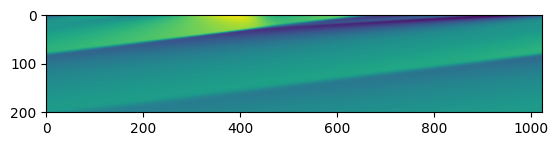

In [49]:
import matplotlib.pyplot as plt

batch_idx = 13
X = 1024
T = 201

image_ori = graph[batch_idx].feat.reshape(T, X).cpu()
plt.imshow(image_ori)

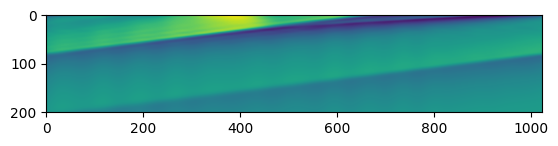

In [50]:
inr.eval()
n_samples = len(graph)

graph.images = graph.feat
graph.pos = graph.space_emb
graph.batch = graph.time
graph.modulations = torch.zeros(graph.T.sum(), latent_dim) #torch.zeros_like(graph.latent_vector)
# graph.modulations = torch.zeros_like(graph.latent_vector)
inr.to(device)
graph.to(device)
alpha = alpha.to(device)
outputs = outer_step(
    inr,
    graph,
    inner_steps,
    alpha,
    is_train=False,
    return_reconstructions=False,
    gradient_checkpointing=False,
    use_rel_loss=False,
    loss_type="mse",
)
predict_modulation = outputs['modulations']

graphbatch= graph[batch_idx].time
pos = graph[batch_idx].space_emb
features_recon = inr.modulated_forward(pos, predict_modulation[graphbatch])
image_recon = features_recon.reshape(T, X).detach().cpu()
plt.imshow(image_recon)